In [1]:
import sys
import os
sys.path += [ f'{os.environ["HOME"]}/.local/lib/python{sys.version_info.major}.{sys.version_info.minor}/site-packages' ]

# Now we can safely import atlasopenmagic
import atlasopenmagic as atom

In [2]:
import uproot # for reading .root files
import time # to measure time to analyse
import math # for mathematical functions such as square root
import awkward as ak # for handling complex and nested data structures efficiently
import numpy as np # # for numerical calculations such as histogramming
import matplotlib.pyplot as plt # for plotting
from matplotlib.ticker import MaxNLocator,AutoMinorLocator # for minor ticks
from lmfit.models import PolynomialModel, GaussianModel # for the signal and background fits
import vector #to use vectors
import requests # for HTTP access
import aiohttp # HTTP client support
import pandas as pd
import json

In [3]:
atom.set_release('2025e-13tev-beta')

Fetching metadata for release: 2025e-13tev-beta...
Fetching datasets: 100%|██████████| 374/374 [00:00<00:00, 1137.28datasets/s]
✓ Successfully cached 374 datasets.
Active release: 2025e-13tev-beta. (Datasets path: REMOTE)


In [4]:
CONFIG_FILE = "config.json"

with open(CONFIG_FILE, "r") as f:
    config = json.load(f)

In [5]:
signal_dsid_list = config["samples"]["signal"]["dsids"]
background_dsid_list = config["samples"]["background"]["dsids"]

signal_nevents = config["samples"]["signal"]["nevents"]
background_nevents = config["samples"]["background"]["nevents"]

variables = config["variables"]

lumi = config["options"]["lumi"]
skim = config["options"]["skim"]
checkpoint_dir = config["options"]["checkpoint_dir"]

In [6]:
def get_xsec_weight(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
        / metadata["sumOfWeights"]
    )

def get_N_inclusive(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
    )

def get_inclusive_yield(metadata, lumi):
    return (
        lumi * 1000
        * metadata["cross_section_pb"]
        * metadata["genFiltEff"]
        * metadata["kFactor"]
    )

def calc_weight(xsec_weight, weight_arr, data):
    for variable in weight_arr:
        xsec_weight = xsec_weight * data[variable]
    return xsec_weight

In [7]:
def create_objects(data, variables):

    prefixes = {
        "lep": "lep_",
        "jet": "jet_",
        "tau": "tau_",
        "photon": "photon_",
        "largeRJet": "largeRJet_",
        "ScaleFactor": "ScaleFactor_",
        "trig": "trig_",
        "met": "met_"}

    objects = {}

    for variable in variables:
        # special case: met
        if variable == "met":
            if "met" not in objects:
                objects["met"] = {}
            objects["met"]["met"] = data[variable]
            continue

        found = False

        for category, prefix in prefixes.items():
            if variable.startswith(prefix):
                name = variable[len(prefix):]
                if category not in objects:
                    objects[category] = {}
                objects[category][name] = data[variable]
                found = True
                break

        if not found:
            if "info" not in objects:
                objects["info"] = {}
            objects["info"][variable] = data[variable]

    # zip everything
    for category in objects:
        objects[category] = ak.zip(objects[category], depth_limit=1)

    return objects

In [8]:
def create_blackbox(signal_dsid_list, background_dsid_list, variables, signal_nevents, background_nevents, lumi=36, 
                    skim="noskim", checkpoint_dir="blackbox_checkpoint",):
    
    print("Variables:", variables)

    # create checkpoint directories
    events_dir = os.path.join(checkpoint_dir, "events")
    completed_file = os.path.join(checkpoint_dir, "completed_dsids.json")

    os.makedirs(events_dir, exist_ok=True)


    # load checkpoint information
    if os.path.exists(completed_file):

        print(f"Load checkpoint: {checkpoint_dir}")

        with open(completed_file, "r") as f:
            completed_dsids = set(json.load(f))

        print(f"{len(completed_dsids)} DSIDs already processed.")
        print(f"Completed DSIDs: {completed_dsids}")

    else:
        print("No checkpoint found. Start from scratch.")
        completed_dsids = set()


    # calculate inclusive yields
    yield_dict = {}

    signal_yield_sum = 0
    background_yield_sum = 0

    for dsid in signal_dsid_list:

        metadata = atom.get_metadata(dsid)
        inc_yield = get_inclusive_yield(metadata, lumi)

        yield_dict[dsid] = inc_yield
        signal_yield_sum += inc_yield


    for dsid in background_dsid_list:

        metadata = atom.get_metadata(dsid)
        inc_yield = get_inclusive_yield(metadata, lumi)

        yield_dict[dsid] = inc_yield
        background_yield_sum += inc_yield


    # calculate number of events per DSID
    nevents_per_sample_dict = {}

    for dsid in signal_dsid_list:
        nevents_per_sample = (signal_nevents / signal_yield_sum * yield_dict[dsid])
        nevents_per_sample_dict[dsid] = nevents_per_sample


    for dsid in background_dsid_list:
        nevents_per_sample = (background_nevents / background_yield_sum * yield_dict[dsid])
        nevents_per_sample_dict[dsid] = nevents_per_sample


    # save completed DSIDs
    def save_completed_dsids():
        with open(completed_file, "w") as f:
            json.dump(sorted(completed_dsids), f, indent=2)
        print(f"Checkpoint information saved: " f"{len(completed_dsids)} completed DSIDs")


    # process samples
    dsid_labels = ([(dsid, 1) for dsid in signal_dsid_list] + [(dsid, 0) for dsid in background_dsid_list])

    for dsid, label in dsid_labels:

        dsid_str = str(dsid)

        print("\n" + "=" * 60)
        print(f"Current DSID: {dsid}")
        print(f"Label: {label}")
        print(f"Already processed: {dsid_str in completed_dsids}")

        # skip already completed DSID
        if dsid_str in completed_dsids:
            print(f"DSID {dsid} already processed -> SKIP")
            continue

        # number of events to collect
        target_events = int(nevents_per_sample_dict[dsid])

        remaining = target_events
        collected_events = 0

        print(f"Target events: {target_events}")

        # temporary storage for this DSID
        chunks = {}
        label_chunks = []

        # get ROOT files
        file_list = atom.get_urls(dsid, skim, protocol="root", cache=False)
        print("Number of files:", len(file_list))

        # loop over ROOT files
        for file_number, afile in enumerate(file_list, start=1):

            print(f"\nProcessing file " f"{file_number}/{len(file_list)}")

            if collected_events >= target_events:
                break

            # read ROOT file chunk-by-chunk
            for data in uproot.iterate(afile + ":analysis", variables, library="ak", step_size=100_000,):

                if len(data) == 0:
                    continue

                # only take events that are still needed
                if len(data) > remaining:
                    data = data[:remaining]

                n_events = len(data)

                # create objects from variable names
                new_objects = create_objects(data, variables)
                label_chunks.append(ak.Array([label] * n_events))

                # save in chunks
                for name, obj in new_objects.items():
                    if name not in chunks:
                        chunks[name] = []
                    chunks[name].append(obj)

                # update counters
                collected_events += n_events
                remaining = target_events - collected_events

                print(f"Collected events: " f"{collected_events}/{target_events}")

                if collected_events >= target_events:
                    break

        # check whether enough events were found
        if collected_events < target_events:
            print(f"WARNING: Only found " f"{collected_events}/{target_events} events " f"for DSID {dsid}.")

        # combine chunks for this DSID
        dsid_arrays = {}

        for name, chunk_list in chunks.items():
            if len(chunk_list) > 0:
                dsid_arrays[name] = ak.concatenate(chunk_list, axis=0)

        # combine labels
        if len(label_chunks) == 0:
            print(f"WARNING: No events collected for DSID {dsid} -> SKIP")
            continue
        dsid_arrays["label"] = ak.concatenate(label_chunks, axis=0)

        # create one Awkward record for this DSID
        dsid_data = ak.zip(dsid_arrays, depth_limit=1)

        # save DSID checkpoint
        checkpoint_file = os.path.join(events_dir, f"dsid_{dsid_str}.parquet")

        print(f"Saving {len(dsid_data)} events to " f"{checkpoint_file}")

        ak.to_parquet(dsid_data, checkpoint_file)

        # mark DSID as completed
        completed_dsids.add(dsid_str)

        save_completed_dsids()


    # load all checkpoint files
    print("\nLoading all checkpoint files...")

    parquet_files = [os.path.join(events_dir, f) for f in os.listdir(events_dir) if f.endswith(".parquet")]

    parquet_files.sort()

    if len(parquet_files) == 0:
        raise RuntimeError("No events found in checkpoint.")

    for parquet_file in parquet_files:
        ds = ak.from_parquet(parquet_file)

    # load and concatenate
    data = ak.from_parquet(parquet_files)

    print(f"Loaded {len(data)} events " f"from {len(parquet_files)} parquet files.")


    # shuffle
    rng = np.random.default_rng(25)
    indices = rng.permutation(len(data))
    data = data[indices]

    # labels
    labels = data["label"]

    return data, labels

In [9]:
data, labels = create_blackbox(signal_dsid_list, background_dsid_list, variables, signal_nevents, background_nevents, skim=skim, lumi=lumi, checkpoint_dir=checkpoint_dir)

Variables: ['lep_pt', 'lep_eta', 'lep_phi', 'lep_e', 'lep_n', 'jet_pt', 'jet_eta', 'jet_phi', 'jet_e', 'jet_n', 'tau_pt', 'tau_eta', 'tau_phi', 'tau_e', 'tau_n', 'photon_pt', 'photon_eta', 'photon_phi', 'photon_e', 'photon_n', 'largeRJet_pt', 'largeRJet_eta', 'largeRJet_phi', 'largeRJet_e', 'ScaleFactor_ElTRIGGER', 'ScaleFactor_FTAG', 'trigP', 'met']
No checkpoint found. Start from scratch.

Current DSID: 301209
Label: 1
Already processed: False
Target events: 10
Number of files: 1

Processing file 1/1
Collected events: 10/10
Saving 10 events to blackbox_checkpoint/events/dsid_301209.parquet
Checkpoint information saved: 1 completed DSIDs

Current DSID: 700323
Label: 0
Already processed: False
Target events: 1
Number of files: 1

Processing file 1/1
Collected events: 1/1
Saving 1 events to blackbox_checkpoint/events/dsid_700323.parquet
Checkpoint information saved: 2 completed DSIDs

Current DSID: 700324
Label: 0
Already processed: False
Target events: 6
Number of files: 1

Processing 

In [10]:
data.lep

<Array [{pt: [15.9, ...], eta: ..., ...}, ...] type='107 * {pt: var * float...'>

In [27]:
def add_leading_pt(obj):
    leadingpt = ak.max(obj["pt"], axis=1, initial=0)

    return ak.with_field(obj, leadingpt, "leading_pt")


def add_subleading_pt(obj):
    sorted_pt = obj["pt"][ak.argsort(obj["pt"], axis=1, ascending=False)]

    subleadingpt = ak.pad_none(sorted_pt, 2, axis=1)[:, 1]

    return ak.with_field(obj, subleadingpt, "subleading_pt")


def add_leading_eta(obj):
    order = ak.argsort(obj["pt"], axis=1, ascending=False)

    sorted_eta = obj["eta"][order]

    leadingeta = ak.pad_none(sorted_eta, 1, axis=1)[:, 0]

    return ak.with_field(obj, leadingeta, "leading_eta")


def add_subleading_eta(obj):
    order = ak.argsort(obj["pt"], axis=1, ascending=False)

    sorted_eta = obj["eta"][order]

    subleadingeta = ak.pad_none(sorted_eta, 2, axis=1)[:, 1]

    return ak.with_field(obj, subleadingeta, "subleading_eta")


def add_leading_phi(obj):
    order = ak.argsort(obj["pt"], axis=1, ascending=False)

    sorted_phi = obj["phi"][order]

    leadingphi = ak.pad_none(sorted_phi, 1, axis=1)[:, 0]

    return ak.with_field(obj, leadingphi, "leading_phi")


def add_subleading_phi(obj):
    order = ak.argsort(obj["pt"], axis=1, ascending=False)

    sorted_phi = obj["phi"][order]

    subleadingphi = ak.pad_none(sorted_phi, 2, axis=1)[:, 1]

    return ak.with_field(obj, subleadingphi, "subleading_phi")


def add_leading_e(obj):
    order = ak.argsort(obj["pt"], axis=1, ascending=False)

    sorted_e = obj["e"][order]

    leadinge = ak.pad_none(sorted_e, 1, axis=1)[:, 0]

    return ak.with_field(obj, leadinge, "leading_e")


def add_subleading_e(obj):
    order = ak.argsort(obj["pt"], axis=1, ascending=False)

    sorted_e = obj["e"][order]

    subleadinge = ak.pad_none(sorted_e, 2, axis=1)[:, 1]

    return ak.with_field(obj, subleadinge, "subleading_e")

def add_di_mass(obj):

    # Sort objects by pt, highest first
    order = ak.argsort(obj["pt"], axis=1, ascending=False)

    pt = obj["pt"][order]
    eta = obj["eta"][order]
    phi = obj["phi"][order]
    e = obj["e"][order]

    # first particle
    px_0 = pt[:, 0] * np.cos(phi[:, 0])
    py_0 = pt[:, 0] * np.sin(phi[:, 0])
    pz_0 = pt[:, 0] * np.sinh(eta[:, 0])
    # second particle
    px_1 = pt[:, 1] * np.cos(phi[:, 1])
    py_1 = pt[:, 1] * np.sin(phi[:, 1])
    pz_1 = pt[:, 1] * np.sinh(eta[:, 1])

    # sum of four-momentum
    sumpx = px_0 + px_1
    sumpy = py_0 + py_1
    sumpz = pz_0 + pz_1
    sumE = e[:, 0] + e[:, 1]

    # invariant mass squared
    rad = (sumE**2 - sumpx**2 - sumpy**2 - sumpz**2)
    # no negative radicand
    rad = ak.where(rad < 0, 0, rad)
    di_mass = np.sqrt(rad)

    obj = ak.with_field(obj, di_mass, "di_mass")
    return obj

def add_deltaR(obj):
    deltaeta = np.abs(obj["leading_eta"] - obj["subleading_eta"])
    deltaphi = obj["leading_phi"] - obj["subleading_phi"]

    deltaphi = np.abs(obj["leading_phi"] - obj["subleading_phi"])
    deltaphi = np.where(deltaphi > 2.0 * np.pi, deltaphi - 2.0 * np.pi, deltaphi)
    deltaphi = np.where(deltaphi >= np.pi, 2.0 * np.pi - deltaphi, deltaphi)

    deltaR = np.sqrt(deltaeta**2 + deltaphi**2)

    obj = ak.with_field(obj, deltaR, "deltaR")

    return obj


def add_delta_phi(obj):
    deltaphi = obj["leading_phi"] - obj["subleading_phi"]
    deltaphi = np.abs(obj["leading_phi"] - obj["subleading_phi"])
    deltaphi = np.where(deltaphi > 2.0 * np.pi, deltaphi - 2.0 * np.pi, deltaphi)
    deltaphi = np.where(deltaphi >= np.pi, 2.0 * np.pi - deltaphi, deltaphi)

    delta_phi = deltaphi / np.pi

    obj = ak.with_field(obj, delta_phi, "delta_phi")

    return obj


def add_delta_eta(obj):
    deltaeta = np.abs(obj["leading_eta"] - obj["subleading_eta"])

    obj = ak.with_field(obj, deltaeta, "delta_eta")

    return obj


In [28]:
data["lep"] = add_leading_pt(data["lep"])
data["lep"] = add_subleading_pt(data["lep"])

data["lep"] = add_leading_eta(data["lep"])
data["lep"] = add_subleading_eta(data["lep"])

data["lep"] = add_leading_phi(data["lep"])
data["lep"] = add_subleading_phi(data["lep"])

data["lep"] = add_leading_e(data["lep"])
data["lep"] = add_subleading_e(data["lep"])

data["lep"] = add_di_mass(data["lep"])
data["lep"] = add_deltaR(data["lep"])
data["lep"] = add_delta_phi(data["lep"])
data["lep"] = add_delta_eta(data["lep"])

In [19]:
data.lep.di_mass

<Array [32.9, 91.6, 92.6, 85, ..., 91.3, 40.8, 31.5, 18.2] type='107 * float64'>

In [20]:
data.lep.leading_pt

<Array [16.5, 47.7, 151, 81.8, ..., 31.5, 16.8, 19.2] type='107 * ?float32'>

In [16]:
data.lep.di_mass

<Array [32.9, 91.6, 92.6, 0.765, ..., 40.8, 31.5, 18.2] type='107 * float64'>

In [24]:
def plot_variable(data, labels, var, min_val, max_val, xlabel, save=None, xlog=True, ylog=True):

    plt.figure(figsize=(8, 5))

    values = data

    for field in var:
        values = values[field]

    values = ak.to_numpy(ak.fill_none(values, np.nan))

    # bins
    if xlog:
        bins = np.logspace(np.log10(min_val), np.log10(max_val), 50)
    else:
        bins = np.linspace(min_val, max_val, 50)

    # signal and background masks
    signal_mask = ((labels == 1) & ~np.isnan(values) & (values >= min_val) & (values <= max_val))
    background_mask = ((labels == 0) & ~np.isnan(values) & (values >= min_val) & (values <= max_val))

    signal = values[signal_mask]
    background = values[background_mask]

    # print integrals
    print(f"Background integral = {len(background)}")
    print(f"Signal     integral = {len(signal)}")

    # plot
    plt.hist([signal, background], bins=bins, stacked=True, label=["Z'", "Background"], histtype="bar")

    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel("Events", fontsize=16)

    plt.tick_params(axis="both", which="major", labelsize=14)

    if xlog:
        plt.xscale("log")

    if ylog:
        plt.yscale("log")

    plt.xlim(min_val, max_val)

    plt.legend(fontsize=13)

    if save is not None:
        plt.savefig(save, bbox_inches="tight")

    plt.show()

In [29]:
plot_variables = [
    (("lep", "di_mass"),               1,       70000, r"$m_{\ell\ell}$ [GeV]",          "mass.pdf",               True, True),
    (("lep", "leading_pt"),     5,       90000, r"Leading lepton $p_T$ [GeV]",    "leading_lep_pt.pdf",    True, True),
    (("lep", "subleading_pt"),  5,       4000, r"Subleading lepton $p_T$ [GeV]", "subleading_lep_pt.pdf", True, True),
    (("lep", "leading_eta"),   -3,          3, r"Leading lepton $\eta$",         "leading_lep_eta.pdf",   False, False),
    (("lep", "subleading_eta"),-3,          3, r"Subleading lepton $\eta$",      "subleading_lep_eta.pdf",False, False),
    (("lep", "leading_phi"),   -np.pi, np.pi, r"Leading lepton $\varphi$",          "leading_lep_phi.pdf",   False, False),
    (("lep", "subleading_phi"),-np.pi, np.pi, r"Subleading lepton $\varphi$",       "subleading_lep_phi.pdf", False, False),
    (("lep", "leading_e"),      5,       90000, r"Leading lepton $E$ [GeV]",       "leading_lep_e.pdf",     True, True),
    (("lep", "subleading_e"),   5,       8000, r"Subleading lepton $E$ [GeV]",    "subleading_lep_e.pdf",  True, True),
    (("lep", "delta_phi"),           0,     np.pi, r"$\Delta\varphi$",                   "deltaPhi.pdf",          False, True),
    (("lep", "delta_eta"),           0,          6, r"$\Delta\eta$",                  "deltaEta.pdf",          False, True),
    (("lep", "deltaR"),             0,          6, r"$\Delta R$",                    "deltaR.pdf",            False, True),
]

Background integral = 97
Signal     integral = 10


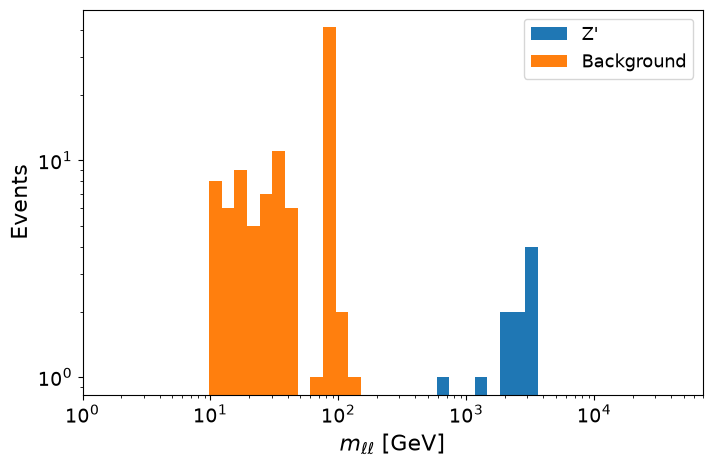

Background integral = 97
Signal     integral = 10


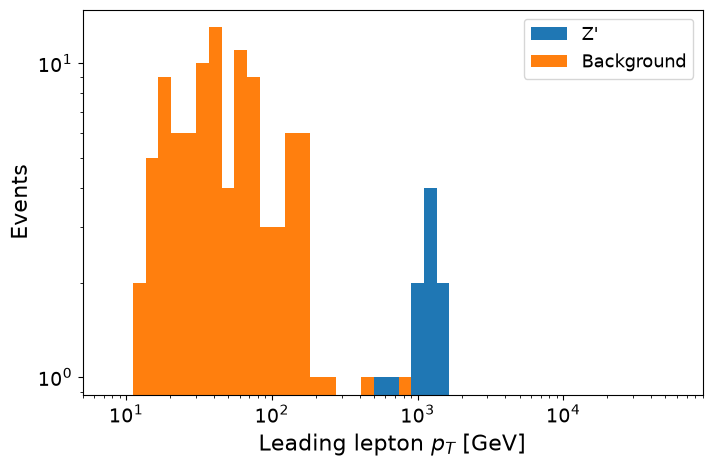

Background integral = 97
Signal     integral = 10


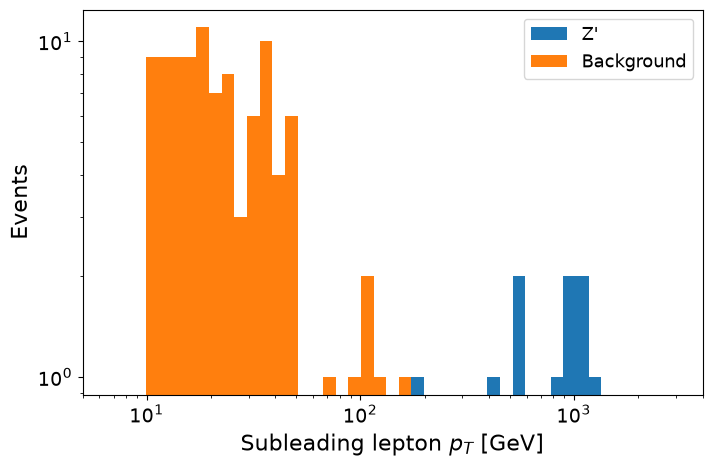

Background integral = 97
Signal     integral = 10


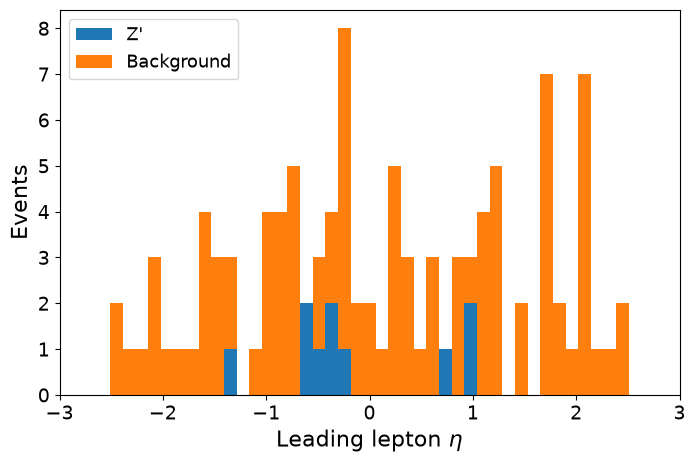

Background integral = 97
Signal     integral = 10


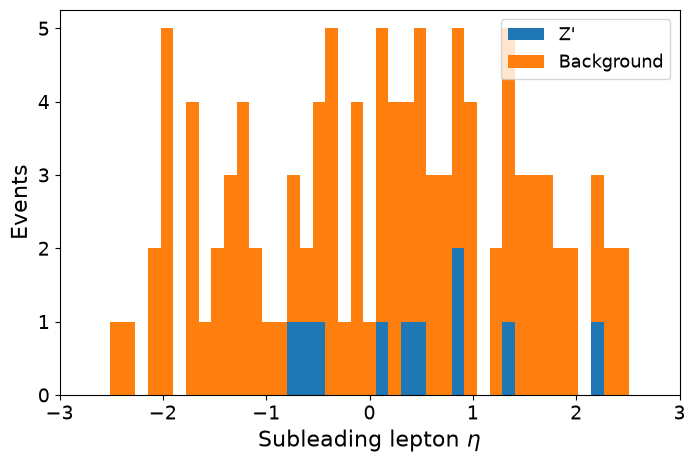

Background integral = 97
Signal     integral = 10


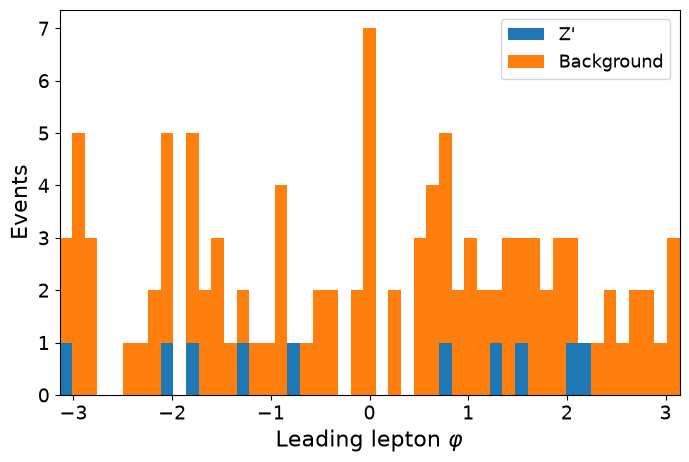

Background integral = 97
Signal     integral = 10


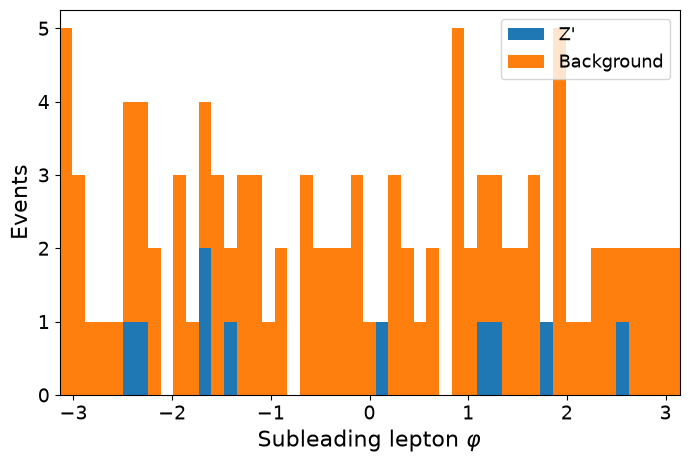

Background integral = 97
Signal     integral = 10


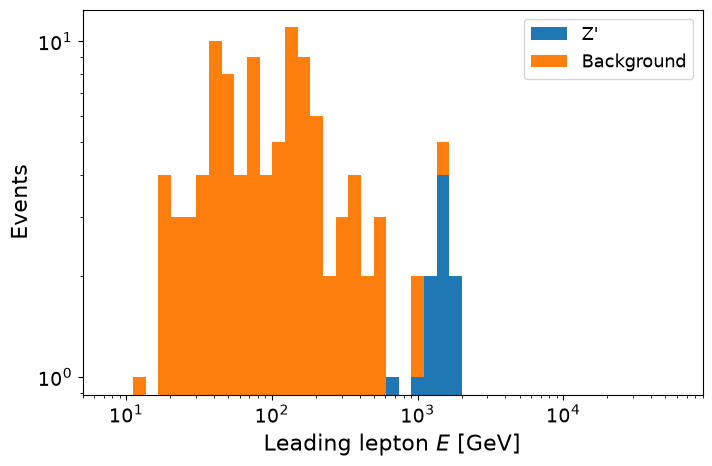

Background integral = 97
Signal     integral = 10


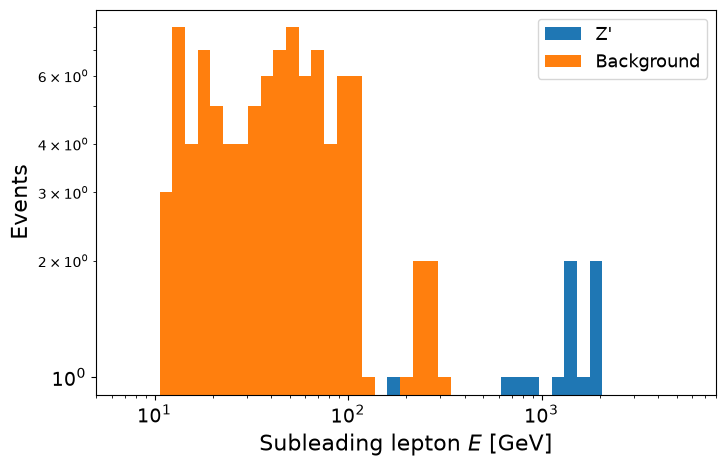

Background integral = 97
Signal     integral = 10


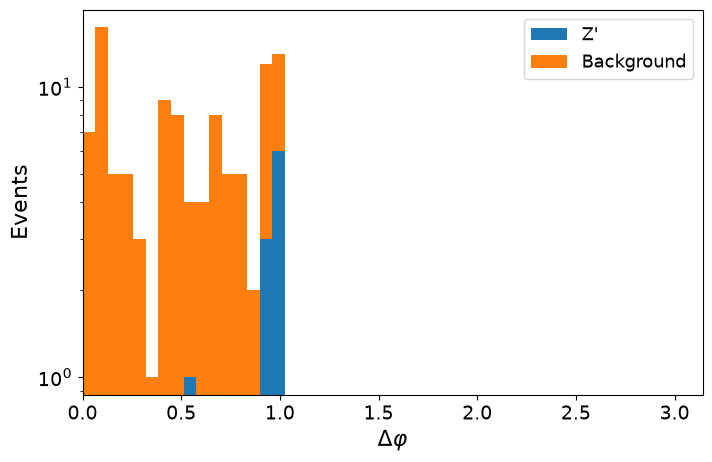

Background integral = 97
Signal     integral = 10


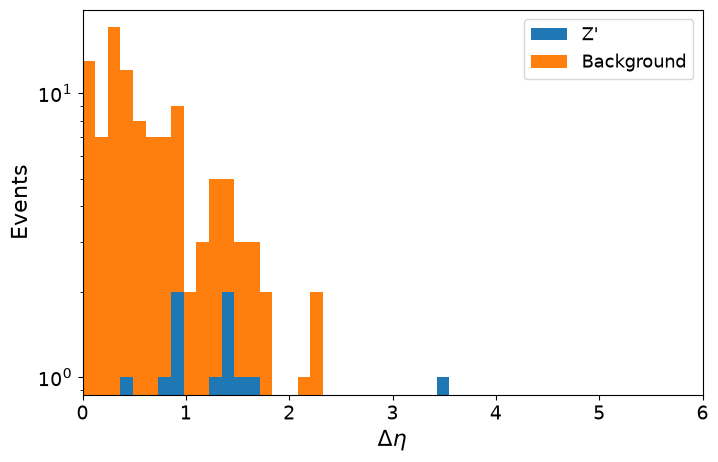

Background integral = 97
Signal     integral = 10


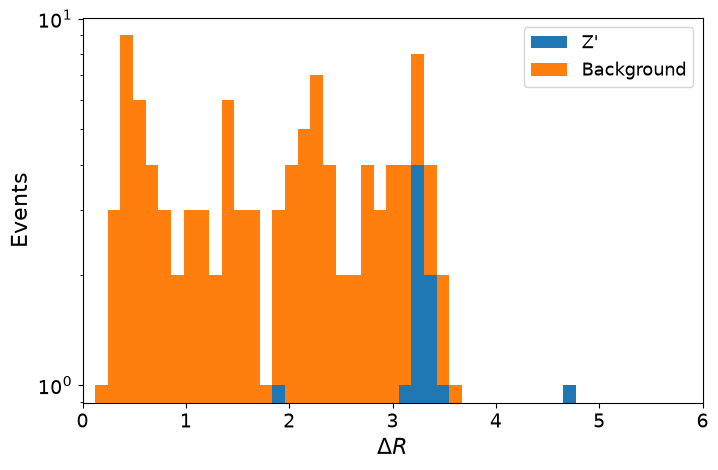

In [31]:
for var, min_val, max_val, xlabel, filename, xlog, ylog in plot_variables:
    plot_variable(data, labels, var=var, min_val=min_val, max_val=max_val, xlabel=xlabel, save="bb_"+filename, xlog=xlog, ylog=ylog)